In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Housing.csv')

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,545.0,4766729.25,1870439.62,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5150.54,2170.14,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.97,0.74,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.29,0.50,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.81,0.87,1.0,1.0,2.0,2.0,4.0
parking,545.0,0.69,0.86,0.0,0.0,0.0,1.0,3.0


In [8]:
#Feature Engineering
df['price_per_sqm'] = df['price'] / df['area']

In [9]:
#Lets map the 'FURNISHING STATUS' Column into ranks,since it is a column having hierachical order to avoid the use of OrdinalEncoder
df['furnishingstatus'] = df['furnishingstatus'].map({
    'unfurnished' : 0,
    'semi-furnished' : 1,
    'furnished' : 2})

#### DATA PREPROCESSING

In [10]:
#Spliting into features and target
X = df.drop(columns = ['price'])
y = df['price']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X.shape

(545, 13)

In [13]:
y.shape

(545,)

In [14]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_sqm
0,7420,4,2,3,yes,no,no,no,yes,2,yes,2,1792.452830
1,8960,4,4,4,yes,no,no,no,yes,3,no,2,1367.187500
2,9960,3,2,2,yes,no,yes,no,no,2,yes,1,1229.919679
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,2,1628.666667
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,2,1537.735849


In [15]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [17]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

In [18]:
num_cols

['area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking',
 'furnishingstatus',
 'price_per_sqm']

In [19]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

In [20]:
cat_cols

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea']

In [21]:
print('shape of X_train:', X_train.shape)
print('shape of X_test:', X_test.shape)
print('shape of y_train:', y_train.shape)
print('shape of y_test:', y_test.shape)

shape of X_train: (436, 13)
shape of X_test: (109, 13)
shape of y_train: (436,)
shape of y_test: (109,)


#### BASELINE MODEL FOR LINEAR REGRESSION

In [22]:
y_mean = y_train.mean()
y_mean

np.float64(4706527.385321101)

In [23]:
y_pred_baseline = [y_mean] * len(y_train)

In [24]:
y_pred_baseline[:5]

[np.float64(4706527.385321101),
 np.float64(4706527.385321101),
 np.float64(4706527.385321101),
 np.float64(4706527.385321101),
 np.float64(4706527.385321101)]

In [25]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error

In [26]:
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)
baseline_mae

1350725.6988048144

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

In [28]:
#Instantiate the transformers
# Numericcal features preprocessing steps
num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

In [29]:
# Categorical features preprocessing steps
cat_imputer = SimpleImputer(strategy="most_frequent")
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [30]:
from sklearn.linear_model import LinearRegression

#### ITERATE

In [31]:
#Straight lines for data types (make_pipeline)
num_processor = make_pipeline(num_imputer, scaler)
cat_processor = make_pipeline(cat_imputer, encoder)

#The column router (make_column_transformer)
baselinehouse_preprocessor = make_column_transformer(
    (num_processor, num_cols), (cat_processor, cat_cols))

# The final baseline pipeline (make_pipeline)
baseline_lr_pipeline = make_pipeline(baselinehouse_preprocessor, LinearRegression())

#### Training the model

In [32]:
#The pipeline handles all imputation, scaling, encoding, and training automatically
baselinehouse_modellr = baseline_lr_pipeline.fit(X_train, y_train)

In [33]:
train_predict = baselinehouse_modellr.predict(X_train)
test_predict = baselinehouse_modellr.predict(X_test)

In [34]:
mae_train = mean_absolute_error(y_train,train_predict)
mae_test = mean_absolute_error(y_test,test_predict)
rmse_train = root_mean_squared_error(y_train,train_predict)
rmse_test = root_mean_squared_error(y_test,test_predict)
r2_train = r2_score(y_train,train_predict)
r2_test = r2_score(y_test,test_predict)

print('MAE_Train:', mae_train)
print('MAE_Test:', mae_test)
print('RMSE_Train:', rmse_train)
print('RMSE_Test:', rmse_test)
print('R2_Train:', r2_train)
print('R2_Test:', r2_test)

MAE_Train: 478209.2193158905
MAE_Test: 503245.2974098998
RMSE_Train: 690496.7726249604
RMSE_Test: 765948.1750205555
R2_Train: 0.8453697309326657
R2_Test: 0.8839314564398744


In [35]:
#The R2 Score is also known as the Coefficent of Determination. Here is another way for clacualting the R2 score

In [36]:
coef_of_dettrain = baselinehouse_modellr.score(X_train, y_train)
coef_of_dettest = baselinehouse_modellr.score(X_test, y_test)

In [37]:
coef_of_dettrain, coef_of_dettest

(0.8453697309326657, 0.8839314564398744)

##### Results obtained from the Linear Regression model trained previousy without the use of A Pipeline

MAE_Train: 478209.2193158906,
MAE_Test: 503245.2974098993,
RMSE_Train: 690496.7726249604,
RMSE_Test: 765948.1750205546,
R2_Train: 0.8453697309326657,
R2_Test: 0.8839314564398747

#### TREE BASED ENSEMBLE MODELS

In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [39]:
from xgboost import XGBRegressor

In [40]:
#import lightgbm as lgb

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [42]:
df.sample(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_sqm
77,6650000,6500,3,2,3,yes,no,no,no,yes,0,yes,2,1023.076923
258,4480000,4040,3,1,2,yes,no,no,no,no,1,no,1,1108.910891


In [43]:
#Create a pipeline
numcols_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

catcols_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'))
])

In [44]:
#Apply the Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numcols_pipeline, num_cols), 
    ('cat', catcols_pipeline, cat_cols)
])

In [45]:
tree_models = {
    'Decision Tree' : DecisionTreeRegressor(random_state=42),
    'Random Forest' : RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boost' : GradientBoostingRegressor(random_state=42)}

In [46]:
#The Baseline State(Untuned) - Instantiating the tree and ensemble algorithms to see its results without changing any of its default settings

In [47]:
baseline_results = {}

for name, model in tree_models.items():
    #Building the pipeline for each model in the FOR Loop
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)])

    #Pipeline train and test
    pipeline.fit(X_train, y_train)

    #Pipeline Predict
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # Evaluate the predictions
    mae_train = mean_absolute_error(y_train, train_pred)
    mae_test = mean_absolute_error(y_test, test_pred)
    mse_train = mean_squared_error(y_train, train_pred)
    mse_test = mean_squared_error(y_test, test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))
    rmse_test  = np.sqrt(mean_squared_error(y_test, test_pred))
    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)
    
    baseline_results[name] = {
        'MAE Train': mae_train,
        'MAE Test': mae_test,
        'MSE Train': mse_train,
        'MSE Test': mse_test,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'R2 Train': r2_train,
        'R2 Test': r2_test
    }

baseline_results

{'Decision Tree': {'MAE Train': 0.0,
  'MAE Test': 369105.50458715594,
  'MSE Train': 0.0,
  'MSE Test': 392016295871.55963,
  'RMSE Train': np.float64(0.0),
  'RMSE Test': np.float64(626112.0473777514),
  'R2 Train': 1.0,
  'R2 Test': 0.9224431995669885},
 'Random Forest': {'MAE Train': 78021.74151376146,
  'MAE Test': 287313.06055045873,
  'MSE Train': 24948444479.169056,
  'MSE Test': 332290569104.164,
  'RMSE Train': np.float64(157950.76599741154),
  'RMSE Test': np.float64(576446.501510907),
  'R2 Train': 0.9919087675446299,
  'R2 Test': 0.9342593825175389},
 'Gradient Boost': {'MAE Train': 79959.73238097565,
  'MAE Test': 258083.16438887274,
  'MSE Train': 11189200987.73037,
  'MSE Test': 182310906843.86343,
  'RMSE Train': np.float64(105779.01960091316),
  'RMSE Test': np.float64(426978.8131088748),
  'R2 Train': 0.9963711394408907,
  'R2 Test': 0.9639314723194988}}

In [48]:
model_results = pd.DataFrame(baseline_results).T  # Transpose to get models as index, metrics as columns
model_results.round(2)

,MAE Train,MAE Test,MSE Train,MSE Test,RMSE Train,RMSE Test,R2 Train,R2 Test
Decision Tree,0.00,369105.50,0.000000e+00,3.920163e+11,0.00,626112.05,1.00,0.92
Random Forest,78021.74,287313.06,2.494844e+10,3.322906e+11,157950.77,576446.50,0.99,0.93
Gradient Boost,79959.73,258083.16,1.118920e+10,1.823109e+11,105779.02,426978.81,1.00,0.96


From the above results,the gradient boosting algorithm is the baseline champion because it successfully explains about 93.99% of the variance in housing prices on unseen data.

Variance Explained (R²): Gradient Boosting explains 96.39% of price variation in unseen housing data, far ahead of Random Forest (93.43%) and Decision Tree (92.24%).

Average Prediction Error(MAE): Gradient Boost predictions deviate by an average of 258,083 per house compared to Decision Tree's 369,105, delivering 111,000 better accuracy per prediction.

Large Mistake Penalty (RMSE): Gradient Boosting's RMSE dropped to 426,978 compared to Decision Tree's 626,112, proving it makes far fewer extreme mispredictions on unusually high or low priced houses.

In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
best_model = GradientBoostingRegressor(random_state=42)

In [51]:
winning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)])

In [52]:
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],      # How many trees
    'model__max_depth': [3, 4, 5],               # How deep can they grow
    'model__learning_rate': [0.01, 0.05, 0.1]    # How fast does it learn
}

In [53]:
grid_search = GridSearchCV(
    estimator = winning_pipeline,
    param_grid = param_grid_xgb, 
    scoring = 'r2', #optimizing based on the R2 Score
    n_jobs = -1, #Using all CPU Cores
    cv = 5, #5 fold validation
    verbose = 1)

In [54]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [55]:
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation R2 Score: {grid_search.best_score_:.4f}")

Best Parameters Found: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 300}
Best Cross-Validation R2 Score: 0.9608


In [56]:
# 1. Extract the fully optimized, retrained winning pipeline
best_tuned_pipeline = grid_search.best_estimator_

# 2. Generate predictions using the tuned champion
y_train_pred = best_tuned_pipeline.predict(X_train)
y_test_pred = best_tuned_pipeline.predict(X_test)

# 3. Calculate explicit final R2 scores
final_train_r2 = r2_score(y_train, y_train_pred)
final_test_r2  = r2_score(y_test, y_test_pred)

print(f"Final Tuned Train R2: {final_train_r2:.4f}")
print(f"Final Tuned Test R2:  {final_test_r2:.4f}")

Final Tuned Train R2: 0.9995
Final Tuned Test R2:  0.9620


The default Gradient Boosting Regressor captured 96.39% of test set variance, though single train-test splits carry risk that high performance may result from favorable random data division rather than genuine model strength.
Grid Search addressed this by testing hyperparameter combinations across 5 separate data rotations (5-fold cross-validation) and selected the optimal configuration: a learning rate of 0.05 for slower and more precise learning steps, a max depth of 4 to capture complex patterns without overfitting, and 300 estimators to thoroughly correct remaining errors. The final tuned test score of approximately 96.2% differs from the baseline by only 0.19%, but this confirms the model maintains its strong performance even under strict cross-validation standards rather than relying on a single lucky split.

#### Scatterplot Showing the "Predicted vs. Actual"

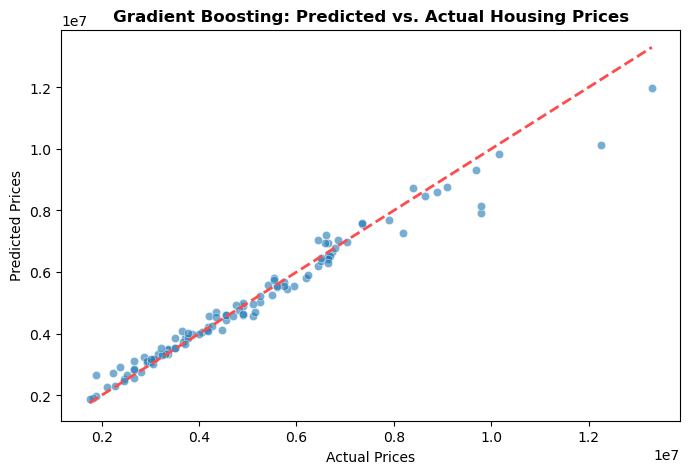

In [57]:
plt.figure(figsize=(7, 5))
# Plot the actual prices vs predicted prices
sns.scatterplot(x=y_test, y=test_pred, alpha=0.6, color='#1F77B4')

# Draw a perfect diagonal line for reference
max_val = max(max(y_test), max(test_pred))
min_val = min(min(y_test), min(test_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='#FF4B4B', linestyle='--', linewidth=2)

plt.title('Gradient Boosting: Predicted vs. Actual Housing Prices', fontsize=12, fontweight='bold')
plt.xlabel('Actual Prices', fontsize=10)
plt.ylabel('Predicted Prices', fontsize=10)
plt.tight_layout()

plt.show()